In [247]:
import os
import pickle
from functools import partial
from time import perf_counter
from typing import Optional

import numpy as np
import tensorflow as tf
from bayesflow import default_settings as defaults
from bayesflow.amortizers import AmortizedPosterior
from bayesflow.helper_networks import MultiConv1D
from bayesflow.networks import InvertibleNetwork
from bayesflow.simulation import GenerativeModel, Prior, Simulator
from bayesflow.trainers import Trainer
from bayesflow.computational_utilities import maximum_mean_discrepancy
from tensorflow.keras.layers import Dense, LSTM, GRU, Bidirectional
from tensorflow.keras.models import Sequential

from helper_functions import measure_bias

In [2]:
job_array_id = int(os.environ.get('SLURM_ARRAY_TASK_ID', 0))
print(f"Job array ID: {job_array_id}")
n_procs = int(os.environ.get('SLURM_CPUS_PER_TASK', 1))

Job array ID: 0


In [3]:
train_network = False
presimulate = False
batch_size = 128
iterations_per_epoch = 1000
# 10000 batches to be generated, 10 epoch until batches are used up
max_epochs = 200  # 100

In [4]:
# possible parameters to fix (as in the simulation study)
fixed_parameters_alpha = {
    "alpha": 0.001,
    "delta": 1.3,
    "mu_inf_SC": 1.,
    "mu_inf_AI": 1.,
    "mu_inf_AC": 1.,
    "mu_susc_C": 1.,
    "mu_protect_acq": 0.8,
    "mu_protect_transm": 1.
}
fixed_parameters_omicron = {
    "alpha": 0.002,
    "delta": 1.4,
    "mu_protect_acq": 0.8,
    "mu_protect_transm": 0.8
}
fixed_parameters_dict = fixed_parameters_alpha

In [5]:
def prior(batch_size: int, fix_parameters: bool = False) -> np.ndarray:
    if not fix_parameters:
        param_batch = np.zeros((batch_size, 12))
        # alpha
        param_batch[:, 0] = np.random.uniform(0, 0.1, batch_size)
        # beta
        param_batch[:, 1] = np.random.uniform(0, 10, batch_size)
        # delta
        param_batch[:, 2] = np.random.uniform(-3, 3, batch_size)
        
        # log transformed parameters
        # mu
        param_batch[:, 3:] = np.random.normal(0, 1, (batch_size, 9))
        #param_batch[:, 3:] = np.exp(np.random.normal(0, 1, (batch_size, 9)))
    else:
        param_batch = np.zeros((batch_size, 4))
        # beta
        param_batch[:, 0] = np.random.uniform(0, 10, batch_size)
        
        # log transformed parameters
        # mu
        param_batch[:, 1:] = np.random.normal(0, 1, (batch_size, 3))
    return param_batch

# for normalization of the parameters
if fixed_parameters_dict is None:
    prior_mean = np.array([0.05, 5, 0, 
                           0, 0, 0, 0, 0, 0, 0, 0, 0])
    prior_std = np.array([1/np.sqrt(12)*(0.1-0), 
                          1/np.sqrt(12)*(10-0),
                          1/np.sqrt(12)*(3+3), 
                          1, 1, 1, 1, 1, 1, 1, 1, 1])
else:
    # prior_mean = np.array([5,
    #                        0, 0, 0, 0, 0, 0, 0])
    # prior_std = np.array([1/np.sqrt(12)*(10-0),
    #                       1, 1, 1, 1, 1, 1, 1])
    prior_mean = np.array([5, 
                           0, 0, 0])
    prior_std = np.array([1/np.sqrt(12)*(10-0), 
                          1, 1, 1])

In [6]:
# check if GPU is available
n_gpus = len(tf.config.experimental.list_physical_devices('GPU'))
print("Num GPUs Available: ", n_gpus)

if n_gpus > 0:
    param_names = ['alpha', 'beta', 'delta',
                   'mu_inf_SC', 'mu_inf_SA', 'mu_inf_AI', 'mu_inf_AC', 'mu_inf_AA',
                   'mu_susc_C', 'mu_susc_A',
                   'mu_protect_acq', 'mu_protect_transm']
    n_households = 128
    length_time_series = 8

    def simulator(params: np.ndarray,
                  variant: str = "alpha",
                  selection_procedure: str = "pedcov",
                  fixed_parameters: Optional[dict] = None)  -> np.ndarray:
        # gpu cannot handle R modules for some reason
        raise NotImplementedError('simulator function not implemented')

else:
    from Simulator.simulator import simulator, param_names

    #_sim = simulator(prior(1).flatten(), fixed_parameters=fixed_parameters_dict)
    n_households = 128 # _sim.shape[0]
    length_time_series = 8 # _sim.shape[1]
    print(f"Number of households: {n_households}, Length of time series: {length_time_series}")
    
# remove fixed parameters from param_names
if fixed_parameters_dict is not None:
    param_names_reduced = param_names.copy()
    for key in fixed_parameters_dict.keys():
        param_names_reduced.remove(key)
    param_names = param_names_reduced  # overwrite, so the original list is not changed
n_params = len(param_names)

Num GPUs Available:  0


Attaching package: ‘dplyr’



    filter, lag



    intersect, setdiff, setequal, union


Attaching package: ‘actuar’



    sd, var



    cm




Number of households: 128, Length of time series: 8


In [7]:
assert n_params == prior(1, fix_parameters=False if fixed_parameters_dict is None else True).shape[1], 'Number of parameters in prior do not match names'
assert n_params == prior_mean.size, 'Number of parameters in normalization do not match names'
print(f"Number of parameters: {n_params}")

Number of parameters: 4


In [8]:
bayesflow_prior = Prior(
    batch_prior_fun=partial(prior, 
                            fix_parameters=False if fixed_parameters_dict is None else True),
    param_names=param_names)
bayes_simulator = Simulator(
    simulator_fun=partial(simulator,
                          selection_procedure='predcov',
                          fixed_parameters=fixed_parameters_dict))
generative_model = GenerativeModel(prior=bayesflow_prior, simulator=bayes_simulator,
                                   skip_test=True,
                                   name="Pedcov Household Sampling")

In [9]:
bayes_simulator_random = Simulator(
    simulator_fun=partial(simulator, 
                          selection_procedure='random',
                          fixed_parameters=fixed_parameters_dict)
)
generative_model_rand = GenerativeModel(prior=bayesflow_prior, simulator=bayes_simulator_random,
                                        skip_test=True,
                                        name="Random Household Sampling")

In [10]:
presim_folder = 'presimulations' if fixed_parameters_dict is None else f'presimulations_with_fixed'

if presimulate:    
    np.random.seed(42)
    print('presimulating')
    start_time = perf_counter()
    from time import sleep
    sleep(job_array_id)

    for job_1000 in range(1):
        add_to_id = job_1000 * 1000
        # we create on batch per job and save it in a folder
        epoch_id = (job_array_id+add_to_id) // iterations_per_epoch
        print(f'presimulating epoch {epoch_id} job {job_array_id+add_to_id}')
        os.makedirs(presim_folder, exist_ok=True)
        generative_model.presimulate_and_save(batch_size=batch_size, 
                                              folder_path=f'{presim_folder}/epoch_{epoch_id}',
                                              iterations_per_epoch=1,
                                              epochs=1,
                                              extend_from=job_array_id+add_to_id,
                                              disable_user_input=True)
    end_time = perf_counter()
    print(f'simulation time: {(end_time-start_time)/60} minutes')
    #exit()

In [11]:
valid_file_name = "valid_data" if fixed_parameters_dict is None else "valid_data_fixed"

np.random.seed(42)
# check if the data exists
if os.path.exists(f'{valid_file_name}.pickle'):
    with open(f'{valid_file_name}.pickle', 'rb') as f:
        valid_data = pickle.load(f)
else:
    print('generating validation data')
    valid_data = generative_model(128)

    # save the data
    with open(f'{valid_file_name}.pickle', 'wb') as f:
        pickle.dump(valid_data, f)

np.random.seed(42)  # same seed as before, so prior samples are the same
# check if the data exists
if os.path.exists(f'{valid_file_name}_rand.pickle'):
    with open(f'{valid_file_name}_rand.pickle', 'rb') as f:
        valid_data_rand = pickle.load(f)
else:
    print('generating validation data random')
    valid_data_rand = generative_model_rand(128)

    # save the data
    with open(f'{valid_file_name}_rand.pickle', 'wb') as f:
        pickle.dump(valid_data_rand, f)

In [12]:
def configurator(forward_dict: dict) -> dict:
    out_dict = {}

    # Extract data (already normalized)
    x = forward_dict["sim_data"]
    idx_keep = np.all(np.isfinite(x), axis=(1, 2, 3))
    out_dict['summary_conditions'] = x[idx_keep].astype(np.float32)
    
    # if simulations contains nan
    if not np.all(idx_keep):
        print(f'Invalid value(s) encountered...removing {idx_keep.size - np.sum(idx_keep)} entry(ies) from batch')
    
    # Extract params
    if 'parameters' in forward_dict.keys():
        forward_dict["prior_draws"] = forward_dict["parameters"]
    if 'prior_draws' in forward_dict.keys():
        params = forward_dict["prior_draws"]
        # normalize
        params = (params - prior_mean) / prior_std
        out_dict['parameters'] = params[idx_keep].astype(np.float32)
    return out_dict

In [13]:
def renormalize_params(params: np.ndarray, param_names: list[str], log_transform: bool = False) -> np.ndarray:
    un_scaled_params = params.copy()
    un_scaled_params = un_scaled_params * prior_std + prior_mean
    
    if log_transform:
        # params might be a batch of samples or single set of parameters
        p_i = 0
        for p_name in param_names:
            if fixed_parameters_dict is not None and p_name in fixed_parameters_dict:
                pass
            # all parameters starting with mu are log transformed, fixed parameters are not transformed
            elif p_name.startswith('mu'):
                if un_scaled_params.ndim == 2:
                    un_scaled_params[:, p_i] = np.exp(un_scaled_params[:, p_i])
                elif un_scaled_params.ndim == 3:
                    un_scaled_params[:, :, p_i] = np.exp(un_scaled_params[:, :, p_i])
                else:
                    raise ValueError('Invalid number of dimensions')
                p_i += 1
            else:
                p_i += 1
    return un_scaled_params

In [14]:
# define the network
class GroupSummaryNetwork(tf.keras.Model):
    """Network to summarize the data of groups of cells.  Each group is passed through a series of convolutional layers
    followed by an LSTM layer. The output of the LSTM layer is then pooled across the groups and dense layer applied
    to obtain a summary of fixed dimensionality. The network is invariant to the order of the groups.
    """
    def __init__(
            self, 
            summary_dim, 
            num_conv_layers=2, 
            rnn_units=128, 
            bidirectional=False,
            conv_settings=None, 
            use_attention=False,
            multi_head_attention=False,
            self_attention=False,
            use_GRU=False,
            **kwargs
    ):
        super().__init__(**kwargs)
        
        if conv_settings is None:
            conv_settings = defaults.DEFAULT_SETTING_MULTI_CONV

        self.conv = Sequential([MultiConv1D(conv_settings) for _ in range(num_conv_layers)])
        self.use_attention = use_attention
        self.multi_head_attention = multi_head_attention
        self.self_attention = self_attention
        
        if self.self_attention:
            self.multi_head_attention = True
        if self.multi_head_attention:
            self.use_attention = True
        
        if use_GRU:
            self.rnn = Bidirectional(GRU(rnn_units, return_sequences=use_attention)) if bidirectional else GRU(rnn_units, return_sequences=use_attention)
        else:
            self.rnn = Bidirectional(LSTM(rnn_units, return_sequences=use_attention)) if bidirectional else LSTM(rnn_units, return_sequences=use_attention)

        if self.multi_head_attention:
            self.attention = tf.keras.layers.MultiHeadAttention(num_heads=4, key_dim=rnn_units)
        elif self.use_attention:
            self.attention = tf.keras.layers.Attention()
            
        if self.self_attention:
            dropout_rate = 0.2
            self.out_layer1 = tf.keras.layers.Dense(3*rnn_units, activation="relu")  # 3 times pooling
            self.out_layer2 = tf.keras.layers.Dense(3*rnn_units, activation="relu")
            self.dropout1 = tf.keras.layers.Dropout(dropout_rate)
            self.dropout2 = tf.keras.layers.Dropout(dropout_rate)
        self.out_layer = Dense(summary_dim, activation="linear")
        self.summary_dim = summary_dim

    def call(self, x, **kwargs):
        """Performs a forward pass through the network by first passing `x` through the same rnn network for
        each household and then pooling the outputs across households.

        Parameters
        ----------
        x : tf.Tensor
            Input of shape (batch_size, n_groups, n_time_steps, n_features)

        Returns
        -------
        out : tf.Tensor
            Output of shape (batch_size, summary_dim)
        """
        # iterate over groups
        out_list = []  # list to store outputs of LSTM for each group
        for g_i in range(x.shape[1]):
            out = self.conv(x[:, g_i], **kwargs)  # (batch_size, n_time_steps, n_filters) -> default: filters=32
            out = self.rnn(out, **kwargs)  # (batch_size, lstm_units) 
            # if attention is used, return full sequence (batch_size, n_time_steps, lstm_units)
            # bidirectional LSTM returns 2*lstm_units
            out_list.append(out)
        if self.use_attention:
            # learn a query vector to attend over the groups, some groups might be more important
            # this should be invariant to the order of the groups (depends on the learned attention mechanism)
            out = tf.stack(out_list, axis=1)  # (batch_size, n_groups, n_time_steps, lstm_units)
            if self.self_attention:  # uses multi-head attention
                out = self.attention(out, out, **kwargs)  # (batch_size, batch_size, lstm_units, lstm_units)
                # Parallel pooling
                max_pool = tf.reduce_max(out, axis=[1, 2])
                avg_pool = tf.reduce_mean(out, axis=[1, 2])
                sum_pool = tf.reduce_sum(out, axis=[1, 2])
                out = tf.concat([max_pool, avg_pool, sum_pool], axis=-1)
                # Residual connections
                out_res = self.out_layer1(out, **kwargs)
                out_res = self.dropout1(out_res, **kwargs)
                out = out_res + out  
                out_res = self.out_layer2(out, **kwargs)
                out_res = self.dropout2(out_res, **kwargs)
                out = out_res + out 
            else:
                query = tf.reduce_mean(out, axis=2)  # (batch_size, n_groups, lstm_units)
                # Reshape query to match the required shape for attention
                query = tf.expand_dims(query, axis=2)  # (batch_size, n_groups, 1, lstm_units)
                if self.multi_head_attention:
                    out = self.attention(query, out, **kwargs)  # (batch_size, n_groups, 1, lstm_units)
                else:
                    out = self.attention(
                        [query, out], **kwargs)  # (batch_size, n_groups, 1, lstm_units)
                out = tf.reduce_sum(out, axis=1)  # (batch_size, 1, lstm_units)
                out = tf.squeeze(out, axis=1)  # Remove the extra dimension (batch_size, lstm_units)
        else:
            # pooling over groups, this totally invariants to the order of the groups
            out = tf.reduce_sum(out_list, axis=0)  #  (batch_size, lstm_units)
        # apply dense layer
        out = self.out_layer(out, **kwargs)  # (batch_size, summary_dim)
        return out

In [15]:
# Attention layer for persons in a household
class PersonAttention(tf.keras.layers.Layer):
    def __init__(self):
        super(PersonAttention, self).__init__()
        self.attention = Dense(1, activation='tanh')

    def call(self, inputs, **kwargs):
        attention_weights = self.attention(inputs, **kwargs)
        attention_weights = tf.nn.softmax(attention_weights, axis=1)
        weighted_sum = tf.reduce_sum(inputs * attention_weights, axis=1)
        return weighted_sum
    

# 4. Putting it all together
class HouseholdSummaryNetwork(tf.keras.Model):
    def __init__(self, input_dim, summary_dim, use_attention=False, use_embedding=False, **kwargs):
        super().__init__(**kwargs)
        self.input_dim = input_dim
        self.person_encoding_dim = [64, 32]
        self.household_encoding_dim = [64, 32]
        self.agg_dim = [64]
        self.use_embedding = use_embedding
        
        if self.use_embedding:
            self.person_encoder = self.create_person_encoder_embedding(4)
        else:        
            self.person_encoder = self.create_person_encoder()
        self.household_aggregator = self.create_household_aggregator(use_attention)
        self.global_aggregator = self.create_global_aggregator()
        self.out_layer = Dense(summary_dim, activation="linear")
        
    # 1. Individual Encoding
    def create_person_encoder_embedding(self, embedding_dim):
        continuous_features = ['date_sympt']
        categorical_features = [['not infected', 'infected and symptomatic', 'infected and asymptomatic'], 
                                ['age under 6', 'age under 11', 'age adult'], 
                                ['not protected', 'protected']]
        
        continuous_input = tf.keras.Input(shape=(len(continuous_features),))
        categorical_inputs = [tf.keras.Input(shape=(len(features)-1,)) for features in categorical_features]
        
        embeddings = []
        for cat_input, features in zip(categorical_inputs, categorical_features):
            embedding = tf.keras.layers.Embedding(input_dim=len(features), output_dim=embedding_dim)(
                tf.range(len(features))[None, :]  # Create indices for all categories including the implicit one
            )  # Shape: (1, num_categories, embedding_dim)
            # Check if all values are -1, then the continuous input is the end-of-follow-up-date
            all_negative_one = tf.reduce_all(tf.equal(cat_input, -1), axis=-1, keepdims=True)
            # Add the implicit category and ensure it's 1 when others are 0
            cat_input_with_implicit = tf.concat([cat_input, 1 - tf.reduce_sum(cat_input, axis=-1, keepdims=True)], axis=-1)
            # Compute weighted embedding
            weighted_embedding = tf.reduce_sum(
                embedding * cat_input_with_implicit[:, :, None],
                axis=1
            )  # Shape: (batch_size, embedding_dim)
            # Replace with all -1s if all inputs were -1
            weighted_embedding = tf.where(all_negative_one, tf.fill(tf.shape(weighted_embedding), -1.0), weighted_embedding)
            embeddings.append(weighted_embedding)
        # output of the embedding layer
        x = tf.keras.layers.Concatenate()(embeddings)

        x = tf.keras.layers.Dense(self.person_encoding_dim[-1]-1, activation='relu')(x)
        x = tf.keras.layers.Concatenate()([continuous_input] + [x])
        return tf.keras.Model(inputs=[continuous_input] + categorical_inputs, outputs=x)
    
    def create_person_encoder(self):
        inputs = tf.keras.Input(shape=(self.input_dim,))
        x = tf.keras.layers.Dense(self.person_encoding_dim[0], activation='relu')(inputs)
        for dim in  self.person_encoding_dim[1:]:
            x = tf.keras.layers.Dense(dim, activation='relu')(x)
        return tf.keras.Model(inputs, x, name="person_encoder")
        
    # 2. Household Aggregation
    def create_household_aggregator(self, use_attention: bool):
        inputs = tf.keras.Input(shape=(None, self.person_encoding_dim[-1]))
        if use_attention:
            x = PersonAttention()(inputs)
        else:
            x = tf.keras.layers.GlobalAveragePooling1D()(inputs)
        for dim in  self.household_encoding_dim:
            x = tf.keras.layers.Dense(dim, activation='relu')(x)
        return tf.keras.Model(inputs, x, name="household_aggregator")
    
    # 3. Global Aggregation
    def create_global_aggregator(self):
        inputs = tf.keras.Input(shape=(None,  self.household_encoding_dim[-1]))
        x = tf.keras.layers.GlobalAveragePooling1D()(inputs)
        for dim in  self.agg_dim:
            x = tf.keras.layers.Dense(dim, activation='relu')(x)
        return tf.keras.Model(inputs, x, name="global_aggregator")

    def call(self, x, **kwargs):
        household_encodings = []
        for household_i in range(x.shape[1]):
            person_encodings = []
            for person_i in range(x[:, household_i].shape[1]):
                if self.use_embedding:
                    continuous_data = x[:, household_i, person_i, 0]
                    categorical_data = [x[:, household_i, person_i, 1:3],
                                        x[:, household_i, person_i, 3:5],
                                        x[:, household_i, person_i, 5]]
                    person_encoding = self.person_encoder([continuous_data] + categorical_data, **kwargs)
                else:
                    person_encoding = self.person_encoder(x[:, household_i, person_i], **kwargs)
                person_encodings.append(person_encoding)
            person_encodings = tf.stack(person_encodings, axis=1)
            household_encoding = self.household_aggregator(person_encodings, **kwargs)
            household_encodings.append(household_encoding)
        
        household_encodings = tf.stack(household_encodings, axis=1)
        out = self.global_aggregator(household_encodings, **kwargs)
        out = self.out_layer(out, **kwargs)
        return out

In [214]:
# settings
net_id = 6

num_conv_layers = 0
use_GRU = True
use_bidirectional_rnn = False
use_attention = False
multi_head_attention = False
self_attention = False
num_coupling_layers = 7
coupling_design = 'spline'
use_cosine_decay = True
use_early_stopping = True
use_household_summary = False
use_embedding = False
coupling_settings = {
    "num_dense": 3,
    "dense_args": dict(
        activation='relu',
        kernel_regularizer=tf.keras.regularizers.l2(1e-4)
    ),
    "dropout_prob": 0.2,
    "bins": 16,
}
summary_loss = None


if net_id == 0:
    amortizer_name = 'amortizer-sampling-bias-0'
elif net_id == 1:
    amortizer_name = 'amortizer-sampling-bias-0-conv'
    num_conv_layers = 2
elif net_id == 2:
    amortizer_name = 'amortizer-sampling-bias-0-attention'
    use_attention = True
elif net_id == 3:
    amortizer_name = 'amortizer-sampling-bias-0-conv-attention'   # calibration seems worse, stopped after only 20 epochs
    num_conv_layers = 2
    use_attention = True
elif net_id == 4:
    amortizer_name = 'amortizer-sampling-bias-0-conv-attention-bid'
    num_conv_layers = 2
    use_attention = True
    use_bidirectional_rnn = True
elif net_id == 5:
    amortizer_name = 'amortizer-sampling-bias-0-conv-multi-attention-bid'  # calibration seems worse, stopped after only 20 epochs
    num_conv_layers = 2
    use_attention = True
    use_bidirectional_rnn = True
    multi_head_attention = True
# elif net_id == 6:
#     amortizer_name = 'amortizer-sampling-bias-0-conv-self-attention'   # TRAP seems a bit off
#     num_conv_layers = 2
#     use_attention = True
#     self_attention = True
# elif net_id == 7:
#     amortizer_name = 'amortizer-sampling-bias-1'  # okay, but RNN worked better
#     use_household_summary = True
# elif net_id == 8:
#     amortizer_name = 'amortizer-sampling-bias-1-person-attention'   # did not work
#     use_household_summary = True
#     use_attention = True
# elif net_id == 9:
#     amortizer_name = 'amortizer-sampling-bias-1-person-attention_embedding'  # did not work, worst
#     use_household_summary = True
#     use_attention = True
#     use_embedding = True
elif net_id == 6:
    amortizer_name = 'amortizer-sampling-bias-0-conv-attention-bid-MMD'  # calibration seems worse, stopped after only 30 epochs
    num_conv_layers = 2
    use_attention = True
    use_bidirectional_rnn = True
    summary_loss = 'MMD'
else:
    raise ValueError('Invalid network id')

if fixed_parameters_dict is not None:
    amortizer_name += '_fixed'

In [215]:
if use_household_summary:
    summary_net = HouseholdSummaryNetwork(input_dim=6, 
                                          summary_dim=n_params*2,
                                          use_embedding=use_embedding,
                                          use_attention=use_attention)
else:
    power_k_hidden_units = int(np.ceil(np.log2(length_time_series)))
    rnn_units = 2**power_k_hidden_units
    rnn_units = rnn_units if rnn_units > 32 else 32   # multiple of 32 hidden units
    summary_net = GroupSummaryNetwork(summary_dim=n_params*2,
                                      rnn_units=rnn_units,
                                      num_conv_layers=num_conv_layers,
                                      use_attention=use_attention,
                                      bidirectional=use_bidirectional_rnn,
                                      multi_head_attention=multi_head_attention,
                                      self_attention=self_attention,
                                      use_GRU=use_GRU)
inference_net = InvertibleNetwork(num_params=n_params,
                                  num_coupling_layers=num_coupling_layers,
                                  coupling_design=coupling_design,
                                  coupling_settings=coupling_settings)

In [216]:
amortizer = AmortizedPosterior(inference_net=inference_net, summary_net=summary_net,
                               summary_loss_fun=summary_loss)
os.makedirs("amortizer", exist_ok=True)
checkpoint_path = 'amortizer/' + amortizer_name
print(checkpoint_path)

# build the trainer with networks and generative model
max_to_keep = 7
trainer = Trainer(amortizer=amortizer,
                  configurator=configurator,
                  generative_model=generative_model,
                  checkpoint_path=checkpoint_path,
                  skip_checks=True,
                  max_to_keep=max_to_keep)

INFO:root:Loaded loss history from amortizer/amortizer-sampling-bias-0-conv-attention-bid-MMD_fixed/history_35.pkl.
INFO:root:Networks loaded from amortizer/amortizer-sampling-bias-0-conv-attention-bid-MMD_fixed/ckpt-35


amortizer/amortizer-sampling-bias-0-conv-attention-bid-MMD_fixed


In [217]:
#summary_net(trainer.configurator(valid_data)['summary_conditions'])

In [218]:
def custom_loader(file_path):
    """Uses pickle to load, but each path is folder with multiple files, each one batch"""
    # load all files in folder
    loaded_presimulations = []
    for file in os.listdir(file_path):
        with open(os.path.join(file_path, file), 'rb') as batch_file:
            batch = pickle.load(batch_file)[0]
            assert isinstance(batch, dict)  # only one batch per file
            loaded_presimulations.append(batch)
    # shuffle list, so iterations are random, only batches stay the same
    np.random.shuffle(loaded_presimulations)
    return loaded_presimulations

In [219]:
if train_network:
    # simulation done before, start training now
    start_time = perf_counter()
    if use_cosine_decay:
        trainer._setup_optimizer(optimizer=None,
                                 epochs=max_epochs,
                                 iterations_per_epoch=iterations_per_epoch)
        optimizer = trainer.optimizer
    else:
        # without cosine decay
        optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005, global_clipnorm=1.0) 

    history = trainer.train_from_presimulation(presimulation_path=presim_folder,
                                               optimizer=optimizer,
                                               max_epochs=max_epochs,
                                               early_stopping=use_early_stopping,
                                               custom_loader=custom_loader,
                                               validation_sims=valid_data)

    end_time = perf_counter()
    print(f'training time: {(end_time-start_time)/60} minutes')
else:
    trainer.load_pretrained_network()
    history = trainer.loss_history.get_plottable()

In [220]:
# Check if training converged
if np.isnan(history['val_losses'].iloc[-1]).any():
    print('Training failed with NaN loss at the end')
    if np.isnan(history['val_losses'].iloc[-max_to_keep:]).all():
        print('Training failed with NaN loss for all latest checkpoints')

# Find the checkpoint with the lowest validation loss out of the last 7
recent_losses = history['val_losses'].iloc[-max_to_keep:]
best_valid_epoch = recent_losses['Loss'].idxmin() + 1  # checkpoints are 1-based indexed
new_checkpoint = trainer.manager.latest_checkpoint.rsplit('-', 1)[0] + f'-{best_valid_epoch}'    
trainer.checkpoint.restore(new_checkpoint)
print("Networks loaded from {}".format(new_checkpoint))

Networks loaded from amortizer/amortizer-sampling-bias-0-conv-attention-bid-MMD_fixed/ckpt-29


# Diagnostic

In [221]:
import bayesflow as bf
from tarp import get_tarp_coverage
from matplotlib import pyplot as plt

In [222]:
results_folder = 'results' if fixed_parameters_dict is None else f'results_with_fixed'

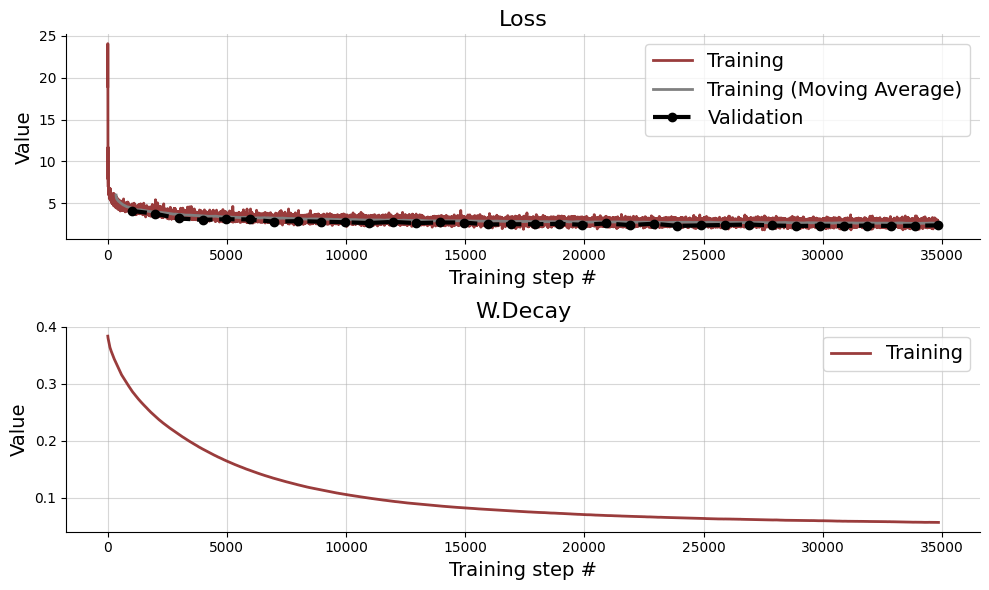

In [223]:
bf.diagnostics.plot_losses(history['train_losses'], history['val_losses'], 
                           moving_average=True, fig_size=(10, 6));

In [224]:
test_sims = trainer.configurator(valid_data)

In [225]:
posterior_samples = amortizer.sample(test_sims, n_samples=100)
posterior_samples = renormalize_params(posterior_samples, param_names)
prior_draws = renormalize_params(test_sims["parameters"], param_names)

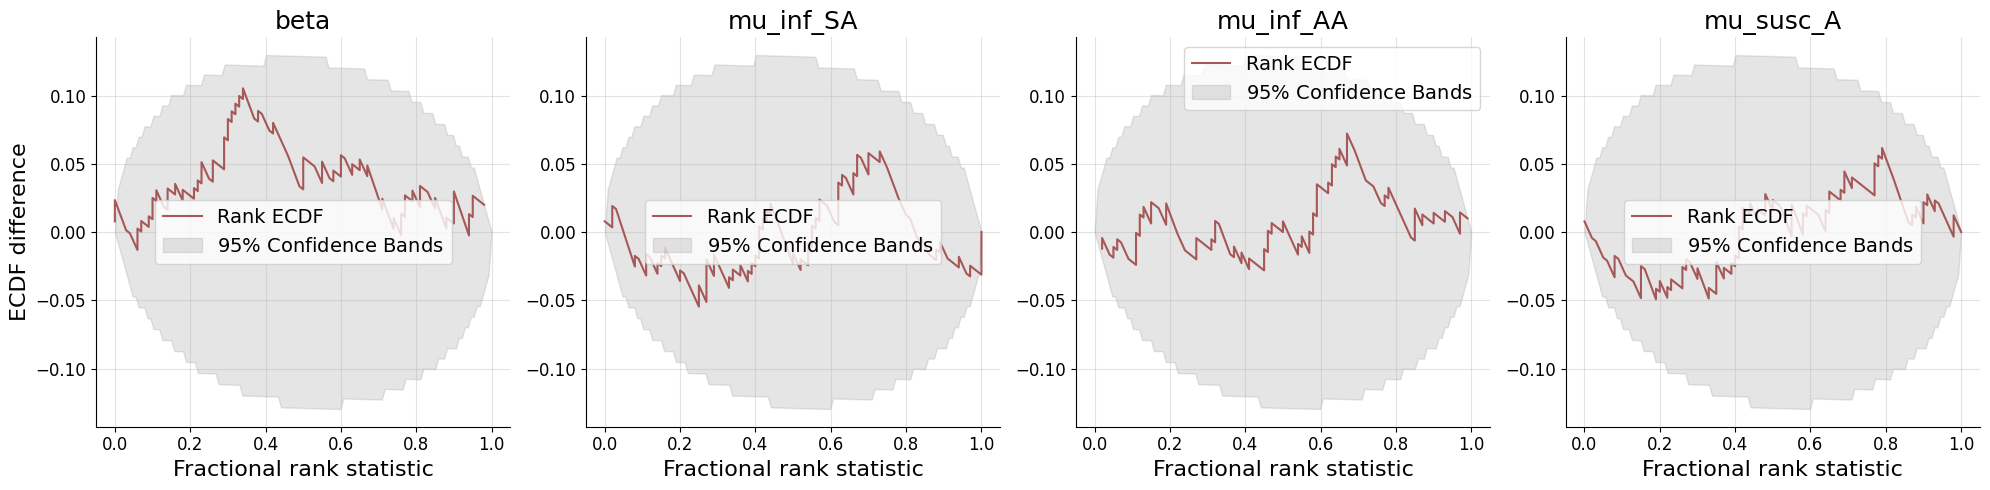

In [226]:
fig = bf.diagnostics.plot_sbc_ecdf(posterior_samples, prior_draws, difference=True, param_names=param_names)
fig.savefig(f'{results_folder}/{amortizer_name}_sbc.png')

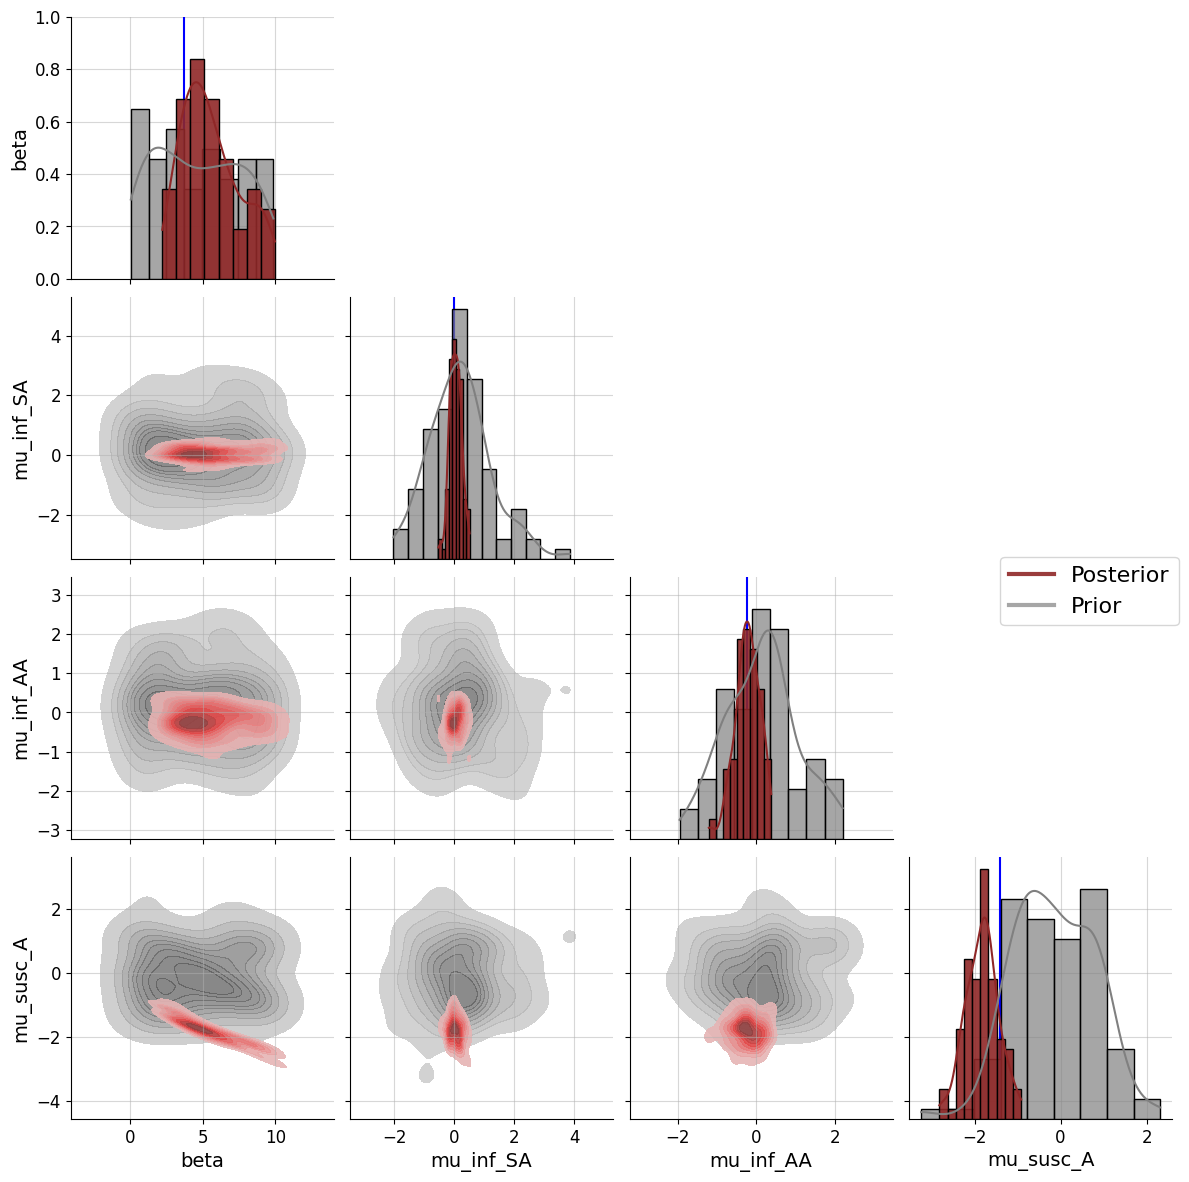

In [227]:
posterior_samples = amortizer.sample(test_sims, n_samples=100)
posterior_samples = renormalize_params(posterior_samples, param_names)
sample_id = 0
fig = bf.diagnostics.plot_posterior_2d(posterior_draws=posterior_samples[sample_id],
                                       prior_draws=prior_draws[:posterior_samples.shape[1]], param_names=param_names)
# from figure get axis
ax = fig.get_axes()
for i, a in enumerate(ax):
    # plot only on the diagonal the true parameter
    if i == i // len(param_names) * (len(param_names) + 1):
        a.axvline(prior_draws[sample_id][i // len(param_names)], color='b', label='True parameter')

In [228]:
# remove nan
remove = np.any(np.isnan(posterior_samples), axis=(1, 2))
if np.any(remove):
    print(f"Removing {np.sum(remove)} entries with nan")

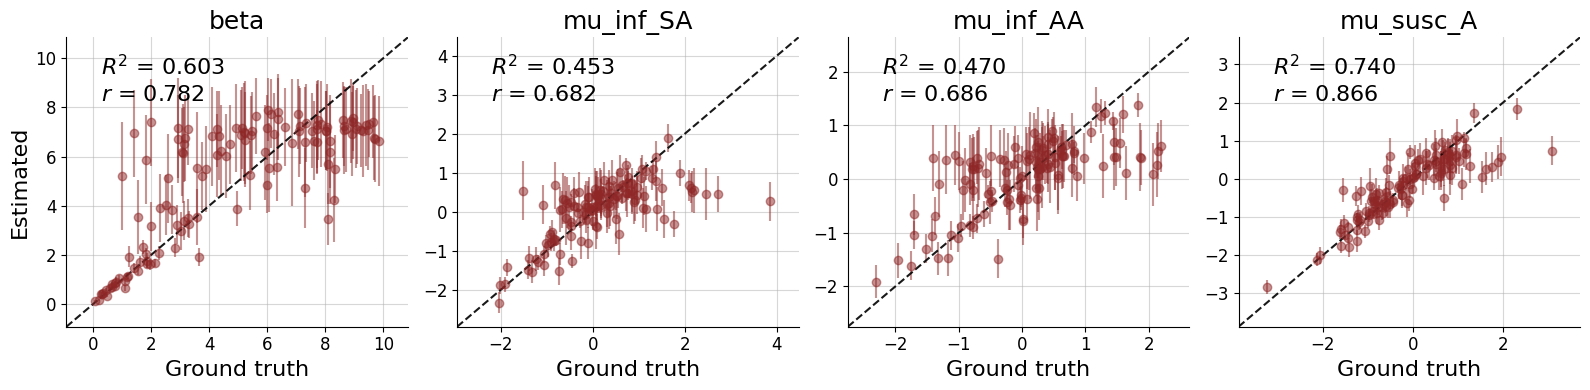

In [229]:
bf.diagnostics.plot_recovery(posterior_samples[~remove], prior_draws[~remove], param_names=param_names);

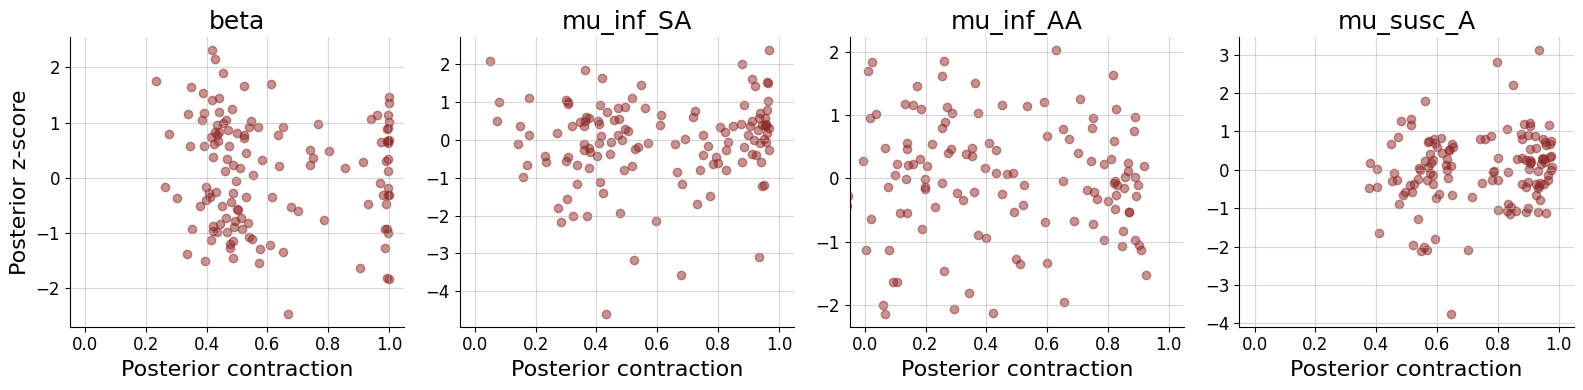

In [230]:
bf.diagnostics.plot_z_score_contraction(posterior_samples, prior_draws, param_names=param_names);

In [231]:
posterior_samples_reshaped = posterior_samples.reshape(posterior_samples.shape[1], posterior_samples.shape[0], posterior_samples.shape[2])

In [232]:
ecp_bootstrap, alpha = get_tarp_coverage(posterior_samples_reshaped, prior_draws, references='random', #posterior_samples_reshaped[0, :, :]
                                         metric='euclidean', norm=True, bootstrap=True)

100%|██████████| 100/100 [00:00<00:00, 1521.37it/s]


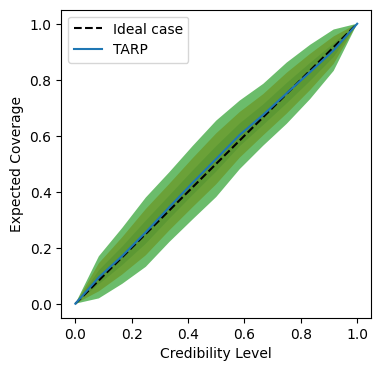

In [233]:
k_sigma = [1, 2, 3]

fig, ax = plt.subplots(1, 1, figsize=(4, 4))
ax.plot([0, 1], [0, 1], ls='--', color='k', label="Ideal case")
ax.plot(alpha, ecp_bootstrap.mean(axis=0), label='TARP')
for k in k_sigma:
    ax.fill_between(alpha, 
                    ecp_bootstrap.mean(axis=0) - k * ecp_bootstrap.std(axis=0), 
                    ecp_bootstrap.mean(axis=0) + k * ecp_bootstrap.std(axis=0), 
                    alpha = 0.7)
ax.legend()
ax.set_ylabel("Expected Coverage")
ax.set_xlabel("Credibility Level")
plt.show()

# Test on synthetic data

In [234]:
np.random.seed(42)
test_sim_name = 'test_data.pickle' if fixed_parameters_dict is None else 'test_data_fixed.pickle'
test_random_sim_name = 'test_data_random.pickle' if fixed_parameters_dict is None else 'test_data_random_fixed.pickle'
if not os.path.exists(test_sim_name):
    test_data = generative_model(1)
    with open(test_sim_name, 'wb') as f:
        pickle.dump(test_data, f)
    true_params = test_data['prior_draws'].flatten()
    random_sim = bayes_simulator_random(true_params[np.newaxis])
    with open(test_random_sim_name, 'wb') as f:
        pickle.dump(random_sim, f)
else:
    with open(test_sim_name, 'rb') as f:
        test_data = pickle.load(f)
    with open(test_random_sim_name, 'rb') as f:
        random_sim = pickle.load(f)
    true_params = test_data['prior_draws'].flatten()
true_params

array([ 3.74540119, -1.11188012,  0.31890218,  0.27904129])

In [235]:
# get posterior samples and simulate
if not os.path.exists(checkpoint_path+'/posterior_sim.npy'):
    test_posterior_samples = amortizer.sample(trainer.configurator(test_data), n_samples=100)
    test_posterior_samples = renormalize_params(test_posterior_samples, param_names)
    
    # simulate the data
    #posterior_sim = bayes_simulator(test_posterior_samples)['sim_data']
    #np.save(checkpoint_path+'/posterior_sim.npy', posterior_sim)
else:
    test_posterior_samples = amortizer.sample(trainer.configurator(test_data), n_samples=100)
    test_posterior_samples = renormalize_params(test_posterior_samples, param_names)
    
    posterior_sim = np.load(checkpoint_path+'/posterior_sim.npy')

In [236]:
prior_draws = partial(prior, fix_parameters=True if fixed_parameters_dict is not None else False)(test_posterior_samples.shape[0])

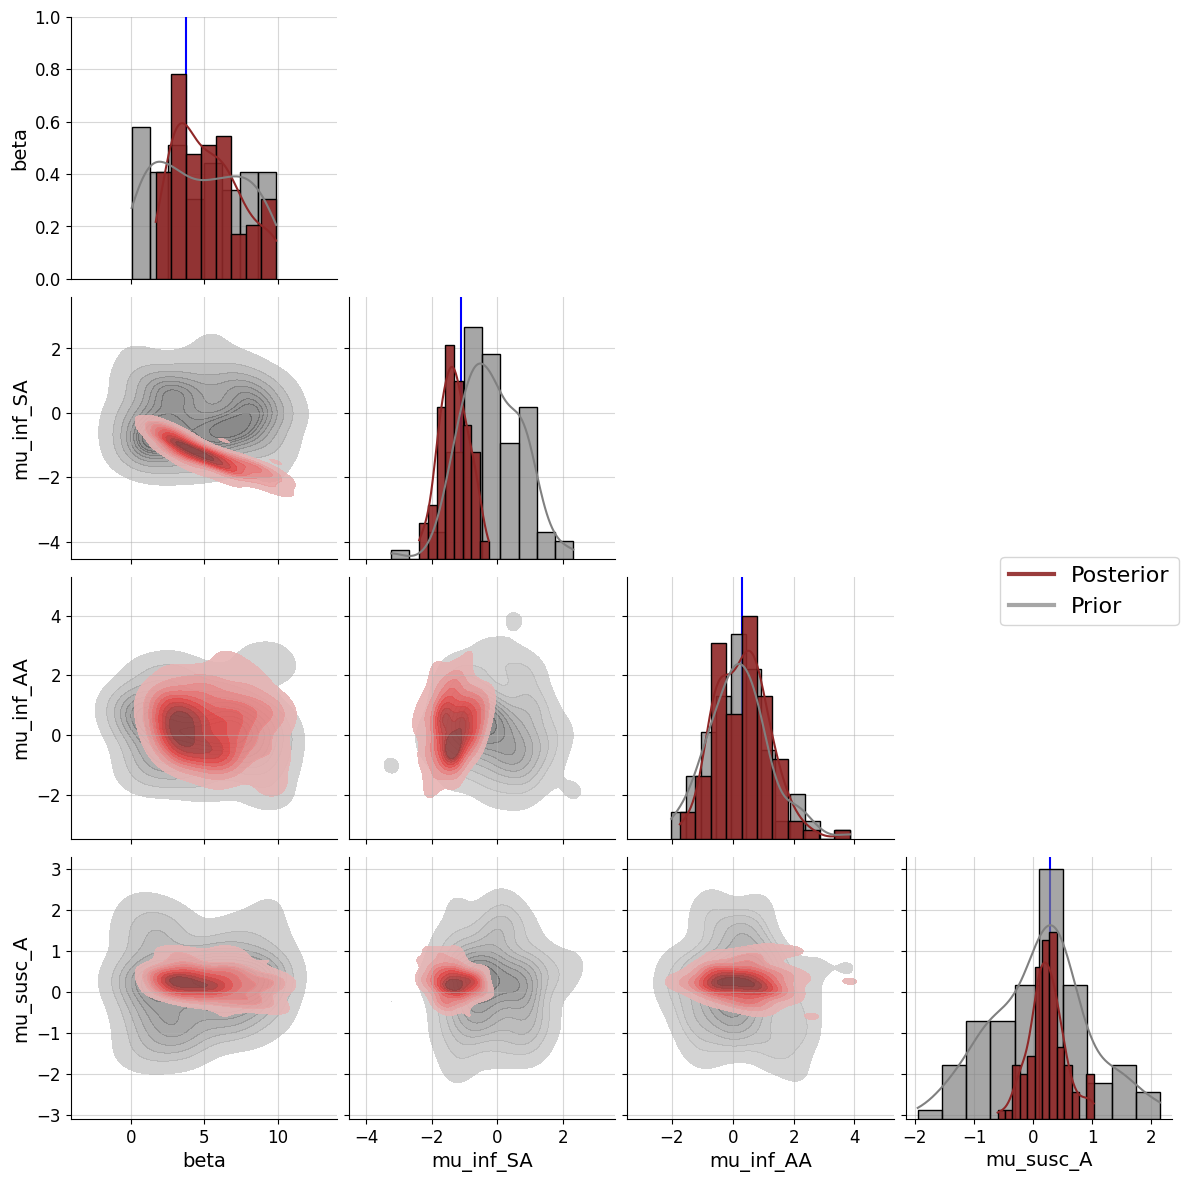

In [237]:
fig = bf.diagnostics.plot_posterior_2d(posterior_draws=test_posterior_samples,
                                       prior_draws=prior_draws, 
                                       param_names=param_names)
# from figure get axis
ax = fig.get_axes()
for i, a in enumerate(ax):
    # plot only on the diagonal
    if i == i // len(param_names) * (len(param_names) + 1):
        a.axvline(true_params[i // len(param_names)], color='b', label='True parameter')

In [238]:
rand_posterior_samples = amortizer.sample(trainer.configurator(random_sim), n_samples=100)
rand_posterior_samples = renormalize_params(rand_posterior_samples, param_names)

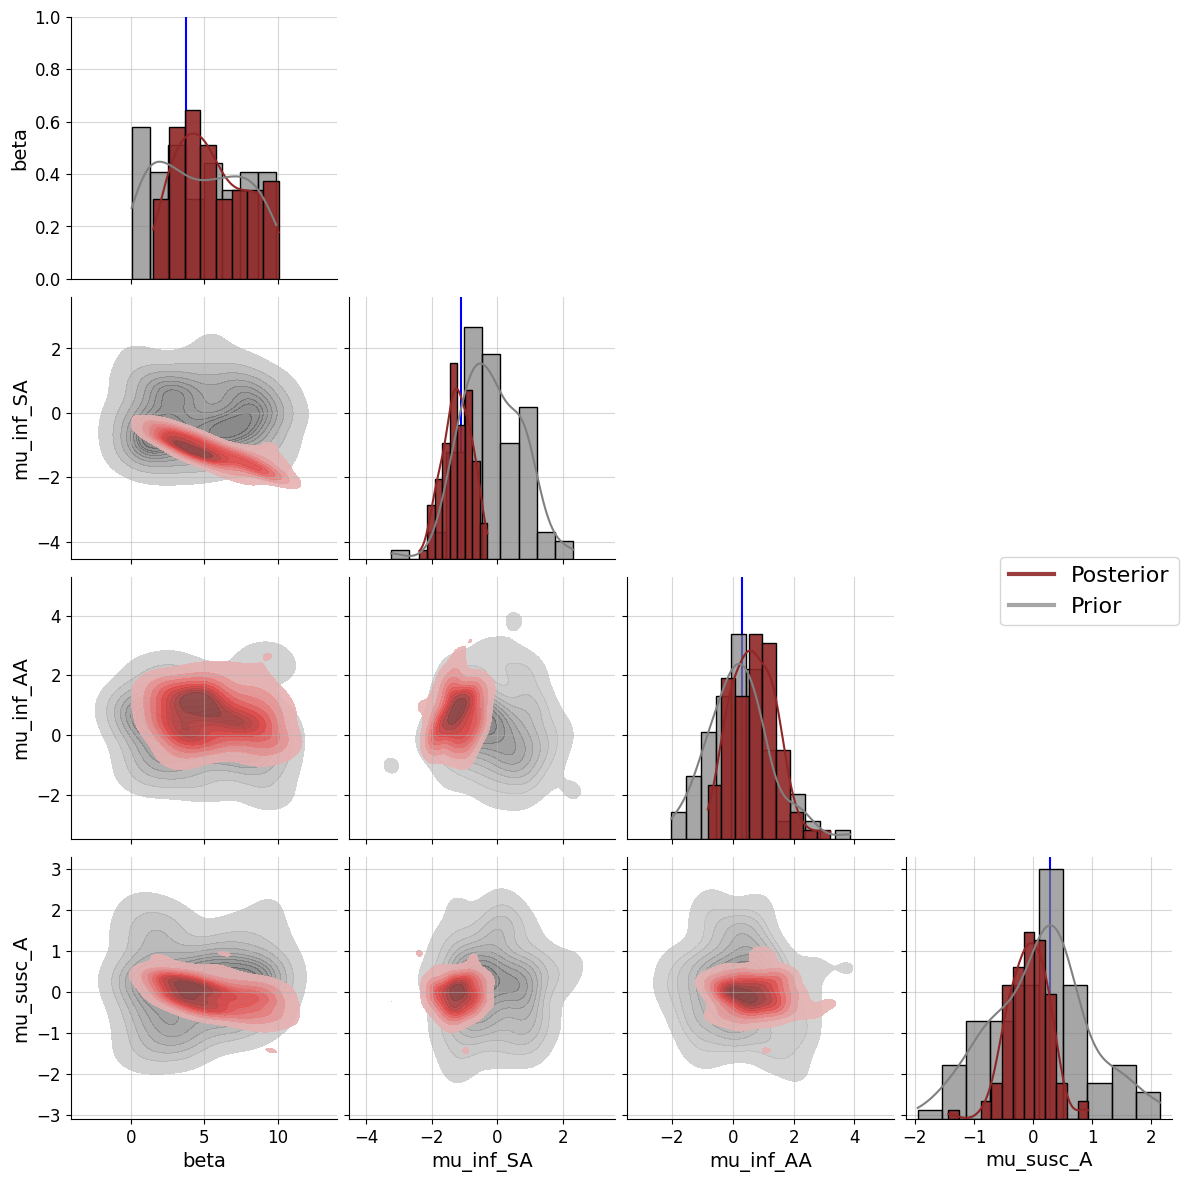

In [239]:
fig = bf.diagnostics.plot_posterior_2d(posterior_draws=rand_posterior_samples,
                                       prior_draws=prior_draws,
                                       param_names=param_names)
# from figure get axis
ax = fig.get_axes()
for i, a in enumerate(ax):
    # plot only on the diagonal
    if i == i // len(param_names) * (len(param_names) + 1):
        a.axvline(true_params[i // len(param_names)], color='b', label='True parameter')

In [240]:
test_sims = trainer.configurator(valid_data)
posterior_samples = amortizer.sample(test_sims, n_samples=100)
posterior_samples = renormalize_params(posterior_samples, param_names)
prior_draws = renormalize_params(test_sims["parameters"], param_names)

test_sims_rand = trainer.configurator(valid_data_rand)
posterior_samples_rand = amortizer.sample(test_sims_rand, n_samples=100)
posterior_samples_rand = renormalize_params(posterior_samples_rand, param_names)
prior_draws_rand = renormalize_params(test_sims_rand["parameters"], param_names)

assert (prior_draws_rand-prior_draws).sum() == 0, 'Prior draws are not the same'

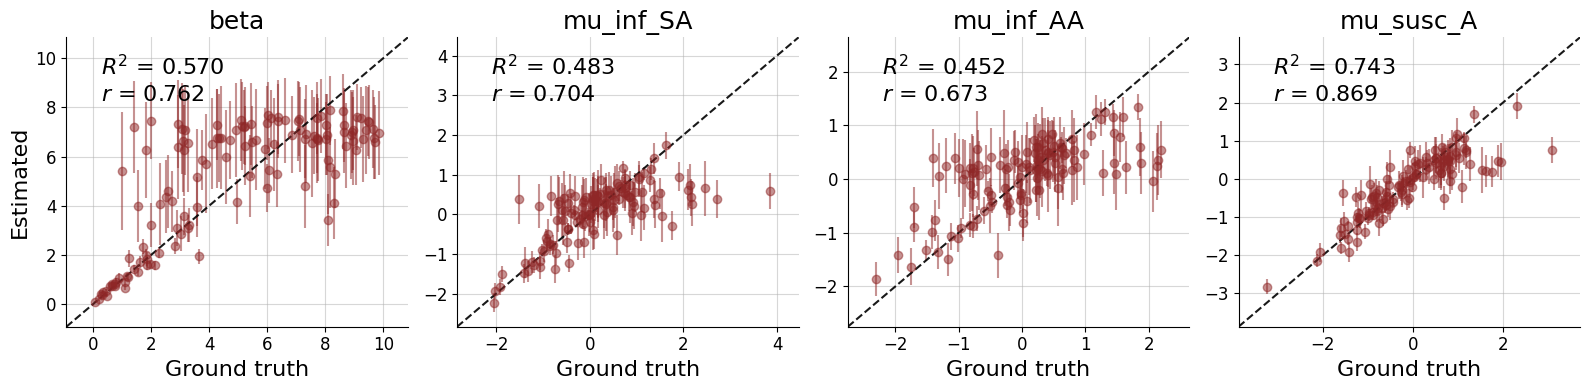

In [241]:
fig = bf.diagnostics.plot_recovery(posterior_samples, prior_draws, param_names=param_names)
fig.savefig(f'{results_folder}/{amortizer_name}_recovery_pedcov.png')

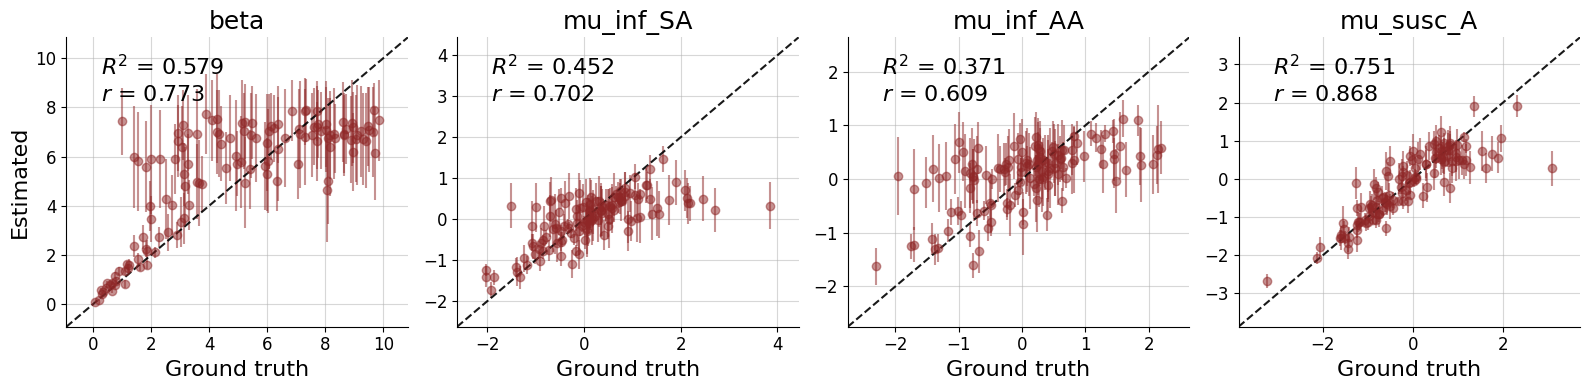

In [242]:
fig = bf.diagnostics.plot_recovery(posterior_samples_rand, prior_draws_rand, param_names=param_names)
fig.savefig(f'{results_folder}/{amortizer_name}_recovery_rand.png')

# Bias Estimation

bias found in simulation study (when using PedCov as selection procedure):
- overestimation of mu_inf_SA, mu_inf_AA (infectiousness of adults)
- underestimation of mu_susc_A (susceptibility of adults)

Since we trained on PedCov, we expect to see a negative bias when using the random selection procedure.

How we got here:
- extensive summary network hyperparameter search
- reduction of model complexity
- changed selection procedure, random or pedcov per household (makes simulation more similar)

In [243]:
bias_per_parameter = measure_bias(np.median(posterior_samples, axis=1),
                                  np.median(posterior_samples_rand, axis=1),
                                  param_names)

print("Bias metrics per parameter - PedCov vs. Random")
print(bias_per_parameter.to_string(index=False))

Bias metrics per parameter - PedCov vs. Random
Parameter  Mean Bias  Mean Percent Bias  Mean Relative Bias  Mean Absolute Error     RMSE
     beta   0.180508          11.060526            0.110605             0.757060 1.061367
mu_inf_SA  -0.134790           3.353618            0.033536             0.340544 0.466098
mu_inf_AA  -0.054501          10.794740            0.107947             0.365612 0.495597
mu_susc_A   0.093864          10.815894            0.108159             0.345326 0.503737


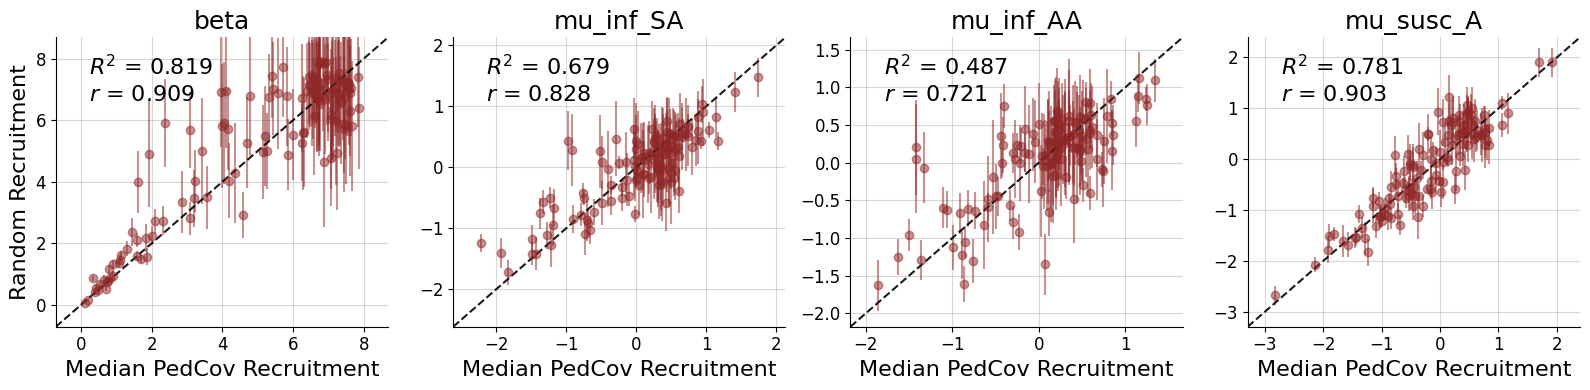

In [244]:
fig = bf.diagnostics.plot_recovery(posterior_samples_rand, np.median(posterior_samples, axis=1), 
                                   param_names=param_names)
# get axis
ax = fig.get_axes()
ax[0].set_ylabel('Random Recruitment')
for a in ax:
    a.set_xlabel('Median PedCov Recruitment')
fig.savefig(f'{results_folder}/{amortizer_name}_recovery_pedcov_vs_rand.png')

In [245]:
bias_per_parameter = measure_bias(prior_draws,  np.median(posterior_samples, axis=1),
                                  param_names)
bias_per_parameter_rand = measure_bias(prior_draws, np.median(posterior_samples_rand, axis=1),
                                  param_names)

print("Bias metrics per parameter - PedCov")
print(bias_per_parameter.to_string(index=False))


print("\nBias metrics per parameter - Random")
print(bias_per_parameter_rand.to_string(index=False))

Bias metrics per parameter - PedCov
Parameter  Mean Bias  Mean Percent Bias  Mean Relative Bias  Mean Absolute Error     RMSE
     beta   0.222613          23.553160            0.235532             1.452388 1.951397
mu_inf_SA  -0.908261          10.798010            0.107980             1.282387 4.543353
mu_inf_AA  -0.379790          26.539959            0.265400             0.818616 1.627257
mu_susc_A  -0.434429           2.861653            0.028617             0.653441 2.034951

Bias metrics per parameter - Random
Parameter  Mean Bias  Mean Percent Bias  Mean Relative Bias  Mean Absolute Error     RMSE
     beta   0.403121          32.350707            0.323507             1.452164 1.930668
mu_inf_SA  -1.043051           6.007734            0.060077             1.305566 4.587239
mu_inf_AA  -0.434291          32.450077            0.324501             0.888635 1.652125
mu_susc_A  -0.340565           6.162062            0.061621             0.676781 2.071475


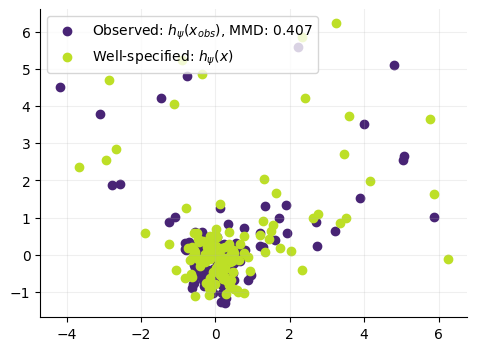

  0%|          | 0/500 [00:00<?, ?it/s]

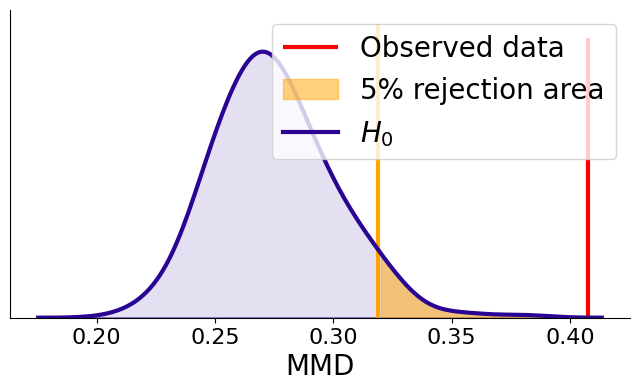

In [260]:
if summary_loss is not None:
    import seaborn as sns
    from matplotlib import cm
    
    summary_statistics = trainer.amortizer.summary_net(test_sims["summary_conditions"])
    summary_statistics_obs = trainer.amortizer.summary_net(test_sims_rand["summary_conditions"])
    mmd = np.sqrt(maximum_mean_discrepancy(summary_statistics, summary_statistics_obs))
    
    fig, ax = plt.subplots(1, 1, figsize=(6, 4))
    colors = cm.viridis(np.linspace(0.1, 0.9, 2))
    ax.scatter(
        summary_statistics_obs[:, 0], summary_statistics_obs[:, 1], 
        color=colors[0], label=r"Observed: $h_{\psi}(x_{obs})$" + f", MMD: {mmd:.3f}"
    )
    ax.scatter(summary_statistics[:, 0], summary_statistics[:, 1], 
               color=colors[1], label=r"Well-specified: $h_{\psi}(x)$")
    ax.legend()
    ax.grid(alpha=0.2)
    plt.gca().set_aspect("equal")
    sns.despine(ax=ax)
    fig.savefig(f'{results_folder}/{amortizer_name} Summary Latent Space.png', bbox_inches='tight')
    plt.show()
    
    MMD_sampling_distribution, MMD_observed = trainer.mmd_hypothesis_test(
        observed_data=test_sims_rand["summary_conditions"], 
        reference_data=test_sims,  # if not provided, will use the generative model
        num_null_samples=500,
        bootstrap=True  # if True, use the reference data as null samples
    )
    fig = bf.diagnostics.plot_mmd_hypothesis_test(MMD_sampling_distribution, MMD_observed)
    fig.savefig(f'{results_folder}/{amortizer_name} MMD.png', bbox_inches='tight')
    plt.show()